# Amazon Reviews Sentiment Analysis Using Natural Language Processing (NLP)

This project applies Natural Language Processing (NLP) techniques to analyze customer reviews from Amazon and classify their sentiments as positive or negative. The workflow includes text preprocessing, exploratory text analysis, feature extraction using TF-IDF vectorization, sentiment classification using machine learning, and model evaluation. The goal is to transform unstructured text data into meaningful insights and develop a predictive model capable of identifying customer sentiment from review content.


## Project Objectives

The objectives of this project are to:

* Clean and preprocess textual review data.
* Explore word patterns and sentiment distributions within the dataset.
* Convert text into numerical features using TF-IDF vectorization.
* Build a machine learning model for sentiment classification.
* Evaluate model performance using classification metrics.
* Generate insights from customer review data.


In [14]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [15]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Dataset Upload

The Amazon Reviews dataset is provided in FastText format. The dataset contains review text and sentiment labels. Reviews labeled as "__label__1" represent negative sentiment, while reviews labeled as "__label__2" represent positive sentiment.


In [1]:
from google.colab import files

uploaded = files.upload()

Saving train.ft.txt.bz2 to train.ft.txt.bz2


## Data Inspection

Before preprocessing the text data, it is important to understand the structure and quality of the dataset. This step involves examining the dataset dimensions, checking for missing values, reviewing sample records, and analyzing the distribution of sentiment labels.


In [6]:
import bz2
import pandas as pd

reviews = []
labels = []

with bz2.open("train.ft.txt.bz2", "rt", encoding="utf-8") as file:

    for i, line in enumerate(file):

        if i >= 50000:
            break

        if line.startswith("__label__"):

            parts = line.split(" ", 1)

            labels.append(parts[0])
            reviews.append(parts[1].strip())

df = pd.DataFrame({
    "sentiment": labels,
    "review": reviews
})

df.head()

,sentiment,review
0,__label__2,Stuning even for the non-gamer: This sound tra...
1,__label__2,The best soundtrack ever to anything.: I'm rea...
2,__label__2,Amazing!: This soundtrack is my favorite music...
3,__label__2,Excellent Soundtrack: I truly like this soundt...
4,__label__2,"Remember, Pull Your Jaw Off The Floor After He..."


In [7]:
df.shape

(50000, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  50000 non-null  object
 1   review     50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
df.head()

,sentiment,review
0,__label__2,Stuning even for the non-gamer: This sound tra...
1,__label__2,The best soundtrack ever to anything.: I'm rea...
2,__label__2,Amazing!: This soundtrack is my favorite music...
3,__label__2,Excellent Soundtrack: I truly like this soundt...
4,__label__2,"Remember, Pull Your Jaw Off The Floor After He..."


In [11]:
df.isnull().sum()

,0
sentiment,0
review,0


In [12]:
df["sentiment"].value_counts()

,count
sentiment,
__label__2,25506
__label__1,24494


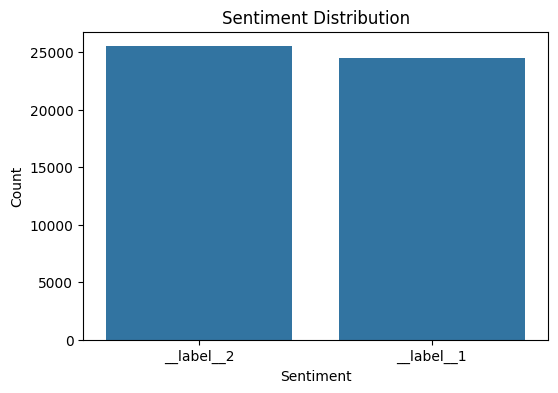

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## Text Preprocessing

Text preprocessing is an essential step in Natural Language Processing (NLP). Raw text data often contains punctuation, special characters, inconsistent capitalization, and common words that may not contribute meaningful information. Preprocessing improves text quality, reduces noise, and prepares the data for feature extraction and machine learning modeling.


In [18]:
df_clean = df.copy()

In [20]:
df_clean["sentiment"] = df_clean["sentiment"].replace({
    "__label__1": "Negative",
    "__label__2": "Positive"
})

In [21]:
df_clean["sentiment"].value_counts()

,count
sentiment,
Positive,25506
Negative,24494


In [23]:
stop_words = set(stopwords.words("english"))

In [25]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize using split
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [26]:
df_clean["clean_review"] = df_clean["review"].apply(clean_text)

In [27]:
df_clean[
    ["review", "clean_review"]
].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [28]:
df_clean.head()

,sentiment,review,clean_review
0,Positive,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,Positive,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Positive,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Positive,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,Positive,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


## Exploratory Text Analysis

Exploratory Text Analysis helps uncover patterns, trends, and frequently occurring terms within textual data. By examining word frequencies and visualizing common terms, we can gain insights into customer opinions and recurring themes present in Amazon product reviews.


In [33]:
all_words = " ".join(
    df_clean["clean_review"]
).split()

In [32]:
word_freq = Counter(all_words)

In [34]:
common_words = word_freq.most_common(20)

common_words

[('book', 32175),
 ('one', 19161),
 ('movie', 14980),
 ('great', 14975),
 ('like', 14787),
 ('good', 14461),
 ('read', 13544),
 ('would', 11567),
 ('time', 9643),
 ('get', 9141),
 ('dont', 8731),
 ('really', 8228),
 ('first', 7422),
 ('much', 7301),
 ('even', 7134),
 ('story', 6976),
 ('well', 6895),
 ('love', 6856),
 ('best', 6451),
 ('better', 5710)]

In [35]:
common_df = pd.DataFrame(
    common_words,
    columns=["Word", "Frequency"]
)

common_df

,Word,Frequency
0,book,32175
1,one,19161
2,movie,14980
3,great,14975
4,like,14787
5,good,14461
6,read,13544
7,would,11567
8,time,9643
9,get,9141


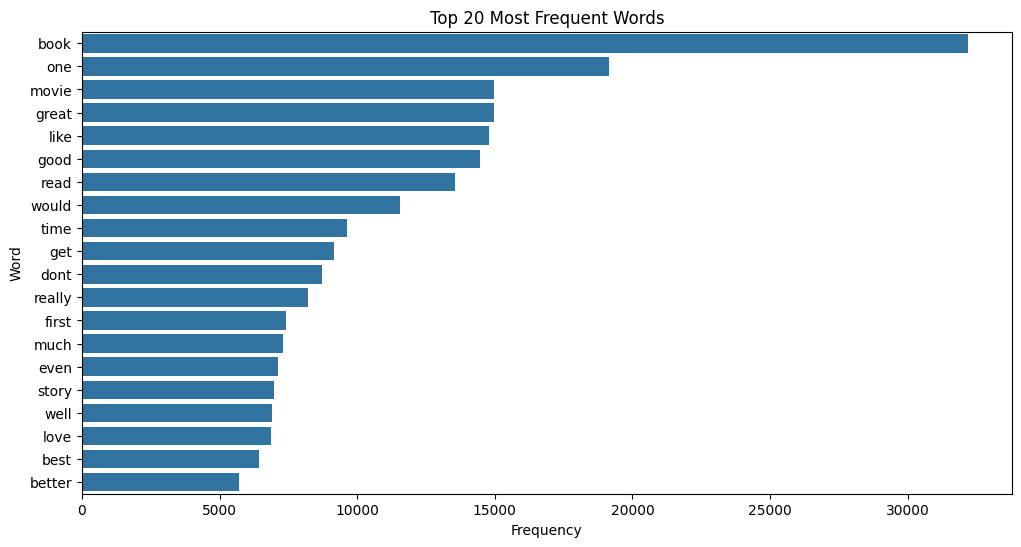

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")

plt.show()

In [39]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(
    " ".join(df_clean["clean_review"])
)

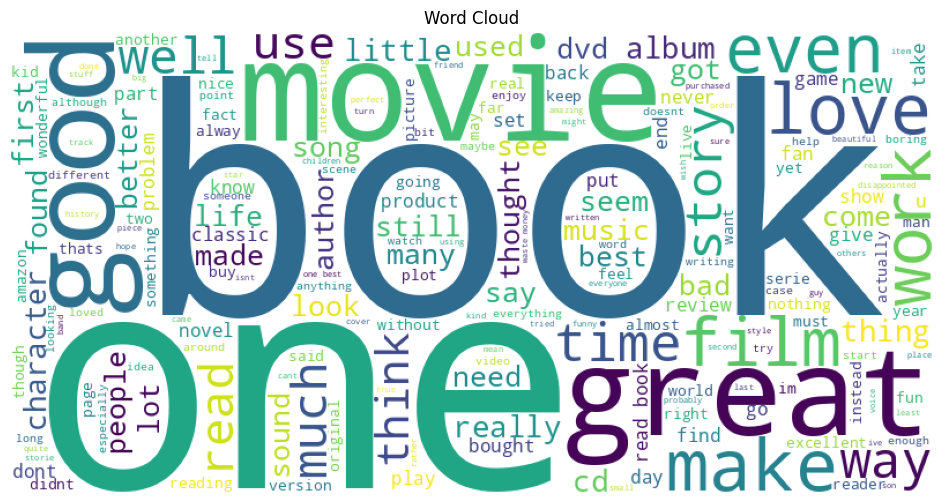

In [40]:
plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

## Text Vectorization Using TF-IDF

Machine learning algorithms cannot process raw text directly. Therefore, the cleaned review text must be converted into numerical features. In this project, TF-IDF (Term Frequency-Inverse Document Frequency) is used to transform text into numerical vectors while assigning greater importance to informative words and reducing the influence of commonly occurring terms.


In [41]:
X = df_clean["clean_review"]

y = df_clean["sentiment"]

In [42]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

In [43]:
X_tfidf.shape

(50000, 5000)

## Data Splitting

The dataset is divided into training and testing sets to evaluate the model's ability to generalize to unseen data. Eighty percent of the data is used for training, while twenty percent is reserved for testing.


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


## Model Development

Logistic Regression was selected as the classification algorithm for this project due to its effectiveness in text classification tasks and its strong compatibility with TF-IDF feature representations.


In [46]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [47]:
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. These metrics provide a comprehensive assessment of the model's classification capability.


In [48]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [49]:
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. These metrics provide a comprehensive assessment of the model's classification capability.


In [50]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8793


In [51]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label="Positive"
)

print("Precision:", precision)

Precision: 0.8714672861014324


In [52]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label="Positive"
)

print("Recall:", recall)

Recall: 0.8923686818632309


In [53]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Positive"
)

print("F1 Score:", f1)

F1 Score: 0.8817941435706591


In [54]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4955
    Positive       0.87      0.89      0.88      5045

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [55]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[4291,  664],
       [ 543, 4502]])

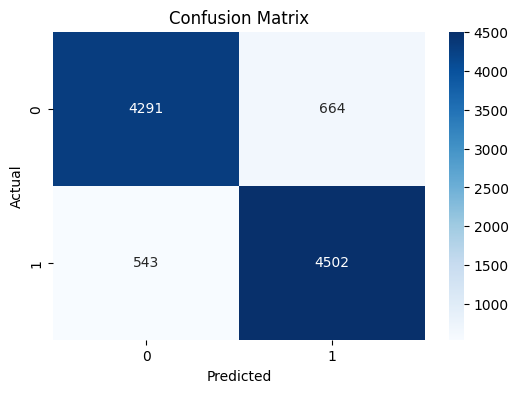

In [56]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Conclusion

This project successfully applied Natural Language Processing (NLP) techniques to analyze Amazon customer reviews and classify their sentiment. The review text was cleaned and preprocessed through lowercasing, removal of special characters, tokenization, and stopword removal. Exploratory text analysis revealed commonly occurring words and key themes within customer feedback.

TF-IDF vectorization was used to transform textual data into numerical features suitable for machine learning. A Logistic Regression model was trained on the processed data and demonstrated strong predictive performance, achieving an accuracy of 87.93%, a precision of 87.15%, a recall of 89.24%, and an F1-score of 88.18%.

The results indicate that the model effectively distinguishes between positive and negative customer reviews. This project demonstrates how NLP and machine learning can be combined to extract valuable insights from large volumes of unstructured text data and support data-driven decision-making.
